# 011 偏导梯度与链式法则

先修009、010。CPU、本地原创配置、NumPy。请在本单元目录重新启动内核并从头运行。参数与梯度均采用(1,2)行，第一列x、第二列y。

本Notebook实际调用核心函数，不使用自动微分。数学条件和解释见lecture.pdf，任务见lab.pdf。

In [1]:
from pathlib import Path
import csv, json, math
import numpy as np
import experiment as lab
from IPython.display import display, Image
print("NumPy", np.__version__)
p = np.array([[2.0, 3.0]])
assert p.shape == (1, 2)

NumPy 2.3.5


## A 手算后再运行
先独立写出a、z、L，以及固定y和固定x的两个斜率。损失64与x偏导64数值相同只是巧合。

In [2]:
values = lab.forward(p)
g = lab.gradient(p)
assert values["loss"] == 64
np.testing.assert_array_equal(g, [[64, 32]])
print(values)
print("行梯度", g, "shape", g.shape)

{'x': 2.0, 'y': 3.0, 'a': 6.0, 'z': 8.0, 'loss': 64.0}
行梯度 [[64. 32.]] shape (1, 2)


## 两条x路径必须相加
经过乘法节点贡献48，直接进入加法节点贡献16。两份共享变量贡献需要累加。

{'x_via_a': 48.0, 'x_direct': 16.0, 'x_total': 64.0, 'y_total': 32.0}


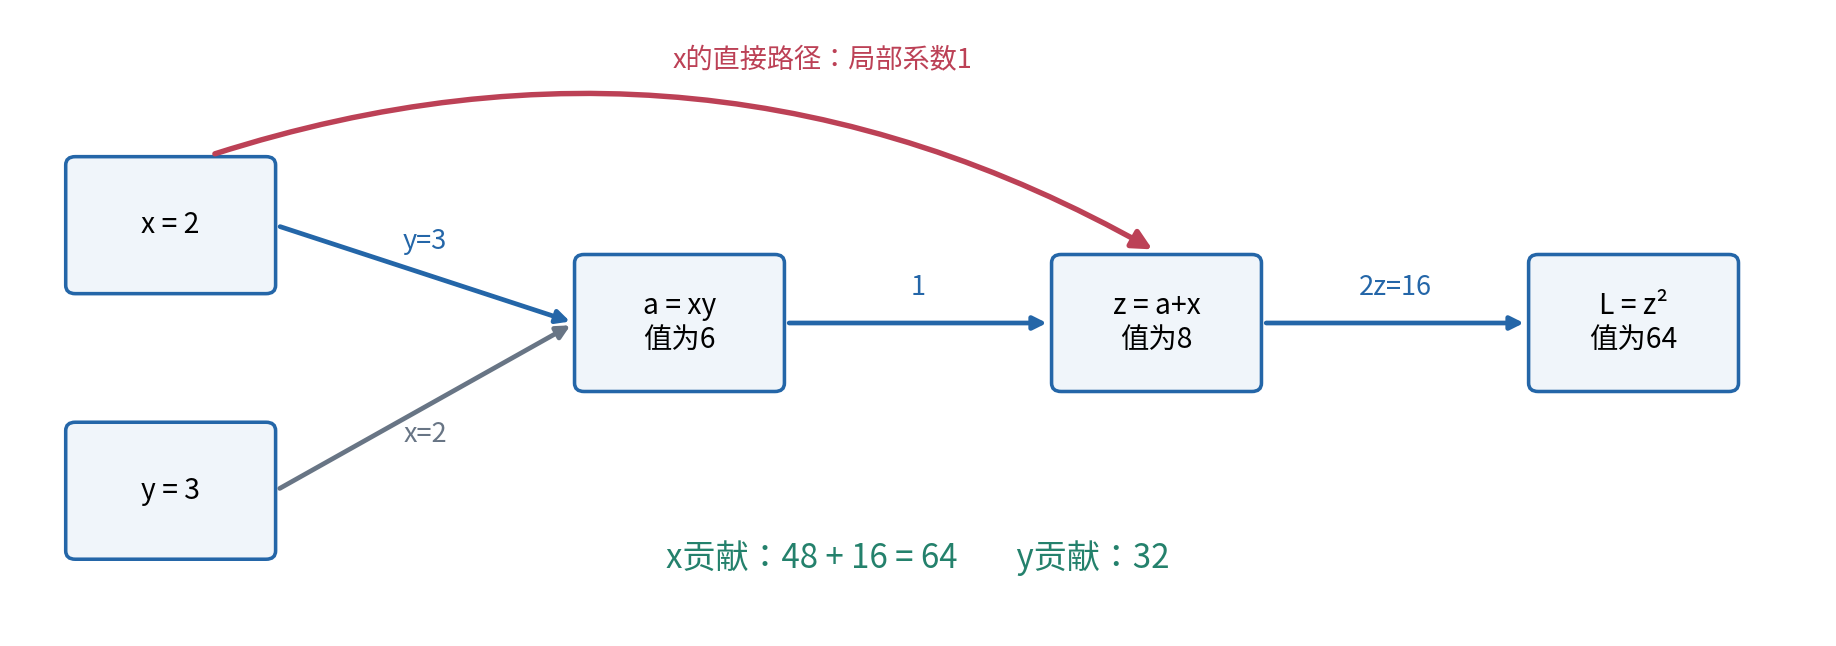

In [3]:
parts = lab.path_contributions(p)
assert parts["x_via_a"] + parts["x_direct"] == 64
print(parts)
display(Image(filename="figures/05_graph.png"))

## C 联合小增量
全微分给线性预测，实际损失还包括余项。沿δ=(ε,2ε)的精确余项为96ε²+32ε³+4ε⁴。

In [4]:
for epsilon in [0.1, 0.01, 0.001]:
    r = lab.linear_prediction(p, [[epsilon, 2*epsilon]])
    exact_remainder = 96*epsilon**2 + 32*epsilon**3 + 4*epsilon**4
    assert abs(r["remainder"] - exact_remainder) < 1e-12
    print(epsilon, r)

0.1 {'delta': [[0.1, 0.2]], 'linear_change': 12.8, 'predicted_loss': 76.8, 'actual_loss': 77.7924, 'remainder': 0.9924000000000035}
0.01 {'delta': [[0.01, 0.02]], 'linear_change': 1.28, 'predicted_loss': 65.28, 'actual_loss': 65.28963203999999, 'remainder': 0.009632039999985409}
0.001 {'delta': [[0.001, 0.002]], 'linear_change': 0.128, 'predicted_loss': 64.128, 'actual_loss': 64.128096032004, 'remainder': 9.60320039951057e-05}


## D 坐标差分和漏路径错误
每次只扰动一个独立坐标，然后重算整个前向过程。错误梯度只漏掉x的直接贡献。

In [5]:
numeric = lab.central_gradient(lab.loss, p, 0.01)
wrong = np.array([[48.0, 32.0]])
np.testing.assert_allclose(numeric, g, atol=1e-9, rtol=0)
assert np.max(np.abs(wrong-g)) == 16
print("数值梯度", numeric)
print("错误梯度与数值核验的差", wrong-numeric)

数值梯度 [[64. 32.]]
错误梯度与数值核验的差 [[-1.60000000e+01  6.82121026e-13]]


## E 单位方向和速度
u=(3/5,4/5)长1；v=(3,4)长5。方向导数按单位距离，路径变化率按参数t，两者差一个速度长度。

In [6]:
u = np.array([[3.0, 4.0]]) / 5
print("单位方向", lab.directional_derivative(p, u))
print("速度(3,4)", lab.rate_along(p, [[3,4]]))
tangent = np.array([[-1.0, 2.0]]) / math.sqrt(5)
assert abs(lab.directional_derivative(p, tangent)) < 1e-12
print("单位切向", lab.directional_derivative(p, tangent))
print("切向有限变化", lab.linear_prediction(p, [[-0.01,0.02]]))

单位方向 64.0
速度(3,4) 320.0
单位切向 0.0
切向有限变化 {'delta': [[-0.01, 0.02]], 'linear_change': 0.0, 'predicted_loss': 64.0, 'actual_loss': 63.99680004000001, 'remainder': -0.0031999599999892325}


## F 联合路线
x=t、y=t+1经过同一点，但两个坐标同时变。路径导数96与偏导64回答不同问题。

In [7]:
rate = lab.rate_along(p, [[1,1]])
assert rate == 96
print("路径导数", rate)
for h in [0.5,0.1,0.01,0.001]:
    estimate = lab.central_curve(2.0, h)
    assert abs(estimate-(96+12*h*h)) < 2e-10
    print("h", h, "中心差分", estimate, "精确截断项", 12*h*h)

路径导数 96.0
h 0.5 中心差分 99.0 精确截断项 3.0
h 0.1 中心差分 96.12000000000009 精确截断项 0.12000000000000002
h 0.01 中心差分 96.00119999999777 精确截断项 0.0012
h 0.001 中心差分 96.00001199999042 精确截断项 1.2e-05


## B 完整运行并查看步长状态
数值栏留空表示未能得到有效结果，不是0。重复运行覆盖notebook_outputs中的实验输出，不修改配置。

In [8]:
report = lab.run(Path("notebook_outputs"))
with Path("notebook_outputs/difference_scan.csv").open() as f:
    scan = list(csv.DictReader(f))
for row in scan:
    print(row)
assert len(scan) == 12
assert scan[-1]["status"] == "Unresolvable input step"

{'h': '0.5', 'gx': '64.0', 'gy': '32.0', 'gradient_max_error': '0.0', 'curve_rate': '99.0', 'curve_error': '3.0', 'status': 'computed'}
{'h': '0.1', 'gx': '64.00000000000001', 'gy': '31.999999999999993', 'gradient_max_error': '1.4210854715202004e-14', 'curve_rate': '96.12000000000009', 'curve_error': '0.12000000000008981', 'status': 'computed'}
{'h': '0.01', 'gx': '63.99999999999899', 'gy': '31.999999999999318', 'gradient_max_error': '1.0089706847793423e-12', 'curve_rate': '96.00119999999777', 'curve_error': '0.0011999999977660991', 'status': 'computed'}
{'h': '0.001', 'gx': '63.99999999999295', 'gy': '31.999999999992923', 'gradient_max_error': '7.077005648170598e-12', 'curve_rate': '96.00001199999042', 'curve_error': '1.1999990420008544e-05', 'status': 'computed'}
{'h': '0.0001', 'gx': '64.000000000064', 'gy': '31.999999999996476', 'gradient_max_error': '6.400568963726982e-11', 'curve_rate': '96.00000012003562', 'curve_error': '1.2003562233076082e-07', 'status': 'computed'}
{'h': '1e-

## G 相同负梯度 不同步长
四次都从同一个起点出发，不要把输出串成递推。大步长可能离开局部下降区间。

{'eta': 0.001, 'new_point': [[1.936, 2.968]], 'old_loss': 64.0, 'new_loss': 59.013861474304, 'linear_predicted_change': -5.12}
{'eta': 0.01, 'new_point': [[1.3599999999999999, 2.68]], 'old_loss': 64.0, 'new_loss': 25.048023039999993, 'linear_predicted_change': -51.2}
{'eta': 0.1, 'new_point': [[-4.4, -0.20000000000000018]], 'old_loss': 64.0, 'new_loss': 12.390399999999998, 'linear_predicted_change': -512.0}
{'eta': 0.5, 'new_point': [[-30.0, -13.0]], 'old_loss': 64.0, 'new_loss': 129600.0, 'linear_predicted_change': -2560.0}


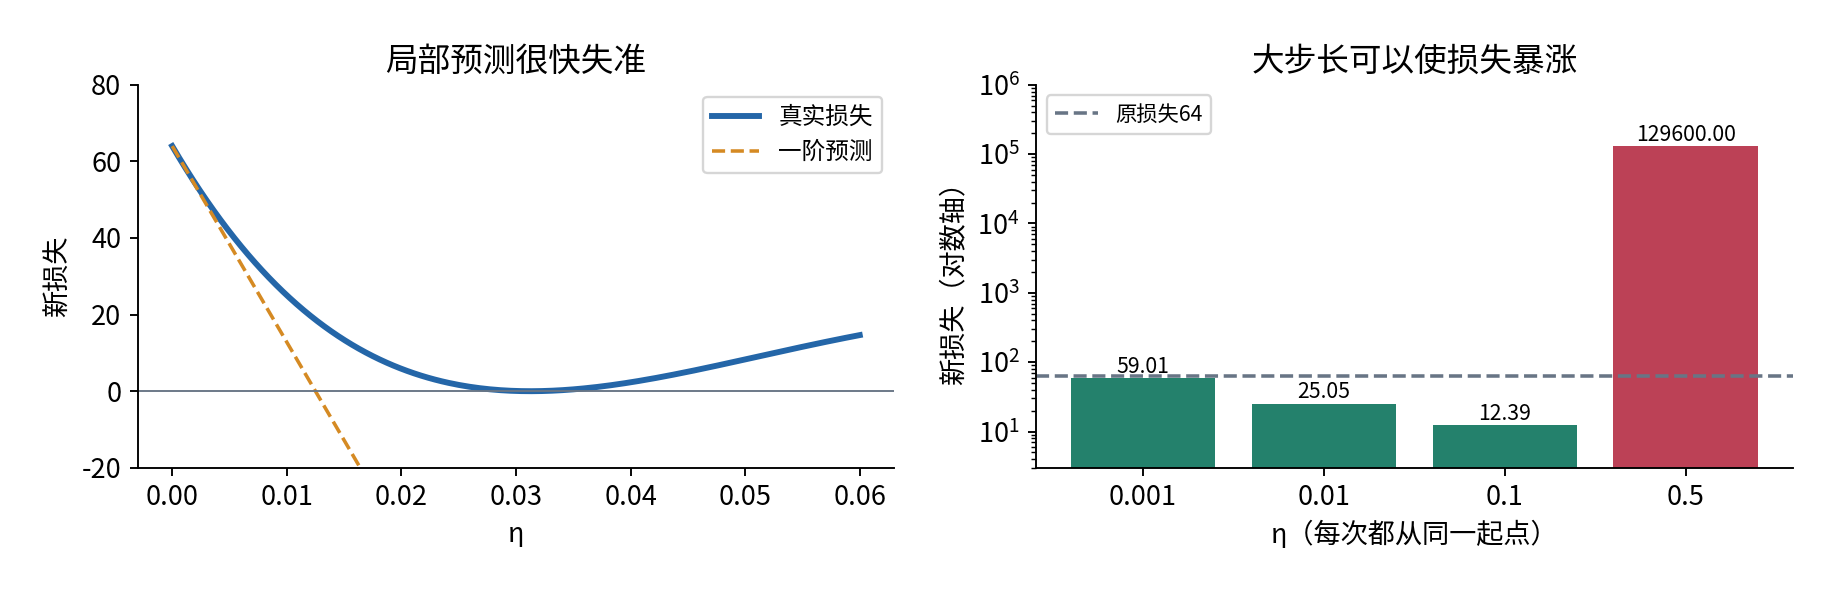

In [9]:
for eta in [0.001,0.01,0.1,0.5]:
    print(lab.gradient_step(p, eta))
assert lab.gradient_step(p, 0.5)["new_loss"] == 129600
display(Image(filename="figures/09_steps.png"))

## H 偏导存在不等于可微
单独反例f=xy/√(x²+y²)，原点为0。两轴平坦，但对角线变成|t|/√2。它连续却不可微。

坐标中心差分 [[0. 0.]]
0.1 右差商 0.7071067811865476 左差商 -0.7071067811865476
0.01 右差商 0.7071067811865476 左差商 -0.7071067811865476
0.001 右差商 0.7071067811865476 左差商 -0.7071067811865476


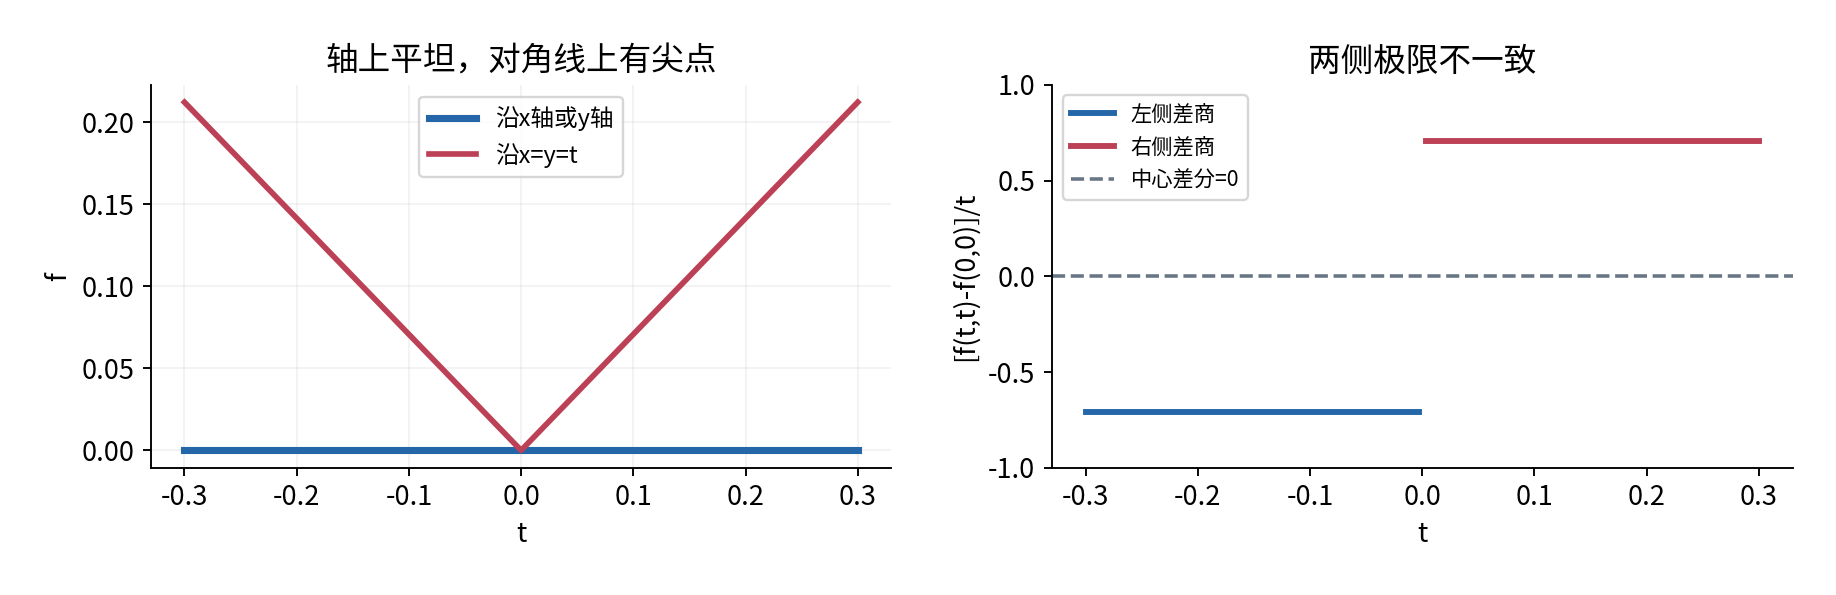

In [10]:
origin = [[0.0,0.0]]
partials = lab.central_gradient(lab.partials_not_enough, origin,0.01)
np.testing.assert_array_equal(partials, [[0,0]])
print("坐标中心差分", partials)
for h in [0.1,0.01,0.001]:
    right = lab.partials_not_enough([[h,h]])/h
    left = lab.partials_not_enough([[-h,-h]])/(-h)
    print(h,"右差商",right,"左差商",left)
    assert abs(right-left-math.sqrt(2)) < 1e-14
display(Image(filename="figures/08_counterexample.png"))

## I 主动拒绝错误输入
错误shape、非单位方向、不可分辨的差分步长必须显式失败。下面捕获预期异常，不把它们作为Notebook错误输出保留。

In [11]:
cases = [("一维点", lambda: lab.gradient([2,3])),
         ("非单位方向", lambda: lab.directional_derivative(p,[[3,4]])),
         ("不可分辨步长", lambda: lab.central_gradient(lab.loss,p,1e-18))]
for name, action in cases:
    try:
        action()
    except (ValueError, TypeError, ArithmeticError) as error:
        print(name, type(error).__name__, str(error))
    else:
        raise AssertionError("Expected failure: " + name)

一维点 ValueError point must have shape (1, 2); got (2,)
非单位方向 ValueError Direction must be unit length; normalize explicitly
不可分辨步长 ArithmeticError Unresolvable input step


## 独立检查器
Fraction检查器使用展开多项式系数，不调用核心gradient生成期望值；80位Decimal再核对路径差分。这些有限测试辅助找错，不代替可微与链式法则的数学条件。

In [12]:
from test_experiment import run_tests
checks = run_tests()
assert checks["status"] == "passed"
print(json.dumps(checks, ensure_ascii=False, indent=2))

{
  "status": "passed",
  "groups": 9,
  "test_groups": [
    "fixed hand calculations and shared-variable path accumulation",
    "81 independent rational expanded-polynomial loss, gradient and central differences",
    "curve central-error identity and 80-digit Decimal oracle",
    "unit direction versus velocity and orthogonal tangent",
    "exact local remainder and finite negative-gradient overshoot",
    "partial existence cannot establish differentiability",
    "32 shape, type, finite-value, step, norm and overflow rejections; no input mutation",
    "full repeated run is byte-identical; altered fixed-report point rejected before writing",
    "all 6 Python document snippets execute in order"
  ],
  "rational_fixtures": 81,
  "rejected_cases": 32,
  "python_snippets": 6
}


## 两次独立执行的输出比较
脚本输出随单元提供。此处检查Notebook重算内容和已执行脚本内容的一致性；字节一致只针对当前固定环境，不作跨平台承诺。

In [13]:
for filename in ["results.json","difference_scan.csv","environment.json"]:
    script = Path("outputs")/filename
    notebook = Path("notebook_outputs")/filename
    assert script.read_bytes() == notebook.read_bytes(), filename
    print(filename, "byte-identical")

results.json byte-identical
difference_scan.csv byte-identical
environment.json byte-identical


## 回到问题

请用自己的话解释：64与32分别固定了谁？48+16为何必须累加？96为何不是64？单位方向导数64与速度变化率320差在哪里？零偏导为什么不足以判断可微？

本Notebook用新Python进程中的真实IPython InProcessKernel顺序执行。沙盒限制socket，未测试浏览器Jupyter界面、跨进程传输或新建conda环境。